In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.8 MB/s eta 0:00:00


In [4]:
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import warnings
warnings.simplefilter('ignore')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
model = YOLO("yolov9m.pt")

In [7]:
results = model.predict(source="Traffic street5.mp4",
save = True, conf = 0.2, iou = 0.5)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/363) /content/Traffic street5.mp4: 384x640 5 persons, 13 cars, 2 traffic lights, 1337.7ms
video 1/1 (frame 2/363) /content/Traffic street5.mp4: 384x640 5 persons, 13 cars, 2 traffic lights, 1608.9ms
video 1/1 (frame 3/363) /content/Traffic street5.mp4: 384x640 5 persons, 12 cars, 2 traffic lights, 1656.9ms
video 1/1 (frame 4/363) /content/Traffic street5.mp4: 384x640 5 persons, 12 cars, 1 traffic light, 1171.4ms
video 1/1 (frame 5/363)

In [8]:
result = results[0]
box = result.boxes[0]

In [9]:
for result in results:
  boxes = result.boxes
  masks = result.masks
  probs = result.probs

In [10]:
for box in result.boxes:
 class_id= result.names[box.cls[0].item()]
 cords = box.xyxy[0].tolist()
 cords =[round(x)for x in cords]
 conf = round(box.conf[0].item(),2)
 print("Object Type:",class_id)
 print("Coordinates:",cords)
 print("probability:",conf)
 print("----")


Object Type: car
Coordinates: [1339, 673, 1670, 809]
probability: 0.91
----
Object Type: car
Coordinates: [716, 683, 916, 815]
probability: 0.86
----
Object Type: person
Coordinates: [1284, 671, 1367, 899]
probability: 0.83
----
Object Type: car
Coordinates: [918, 663, 1060, 765]
probability: 0.81
----
Object Type: person
Coordinates: [649, 660, 761, 878]
probability: 0.8
----
Object Type: person
Coordinates: [1860, 671, 1905, 837]
probability: 0.79
----
Object Type: car
Coordinates: [465, 668, 685, 820]
probability: 0.78
----
Object Type: person
Coordinates: [408, 654, 445, 736]
probability: 0.76
----
Object Type: person
Coordinates: [1730, 669, 1775, 790]
probability: 0.75
----
Object Type: car
Coordinates: [1225, 673, 1273, 710]
probability: 0.72
----
Object Type: person
Coordinates: [445, 649, 479, 727]
probability: 0.7
----
Object Type: person
Coordinates: [1783, 667, 1830, 777]
probability: 0.65
----
Object Type: car
Coordinates: [1042, 677, 1081, 725]
probability: 0.63
----
Obje

(np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5))

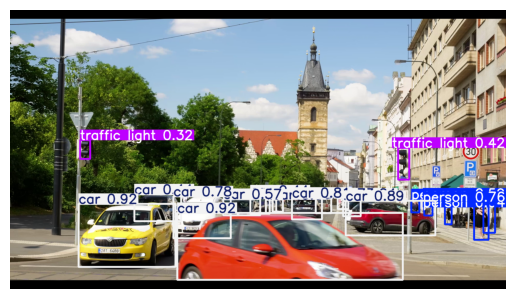

In [11]:
plot = results[0].plot()
plot = cv2.cvtColor(plot,cv2.COLOR_BGR2RGB)
plt.imshow(plot)
plt.axis("off")